# 🏠 Airbnb Listings — Data Cleaning & Exploratory Data Analysis**Objective:** Clean a raw, real-world Airbnb listings dataset and explore pricing, ratings, amenities, and booking-rule patterns across countries.**Dataset:** 14,456 scraped Airbnb listings, 13 raw columns (id, name, rating, reviews, host info, address, features, amenities, safety/house rules, images, price)**Tools:** Python · Pandas · Matplotlib · ydata-profiling**Workflow:** Data Loading → Missing Value & Duplicate Handling → Column-wise Cleaning & Feature Engineering → Exploratory Data Analysis (10 business questions)---

## 1. Setup & Data Loading

In [ ]:
!git clone 'https://github.com/mdooo7/DA-AIRBNB-PROJECT'

In [ ]:
import pandas as pd
df = pd.read_csv('/content/DA-AIRBNB-PROJECT/data/airbnb.csv')

## 2. Initial Data Overview

In [ ]:
df.head()

,id,name,rating,reviews,host_name,host_id,address,features,amenities,safety_rules,hourse_rules,img_links,price
0,49849504,Perla bungalov,4.71,64,Entire bungalow hosted by Mehmetcan,357334205.0,"Kartepe, Kocaeli, Turkey","2 guests,2 bedrooms,1 bed,1 bathroom","Mountain view,Valley view,Lake access,Kitchen,...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: Flexible,Check out: 12:00 pm,Pets ar...",https://a0.muscache.com/im/pictures/a5da5cb7-c...,"₹8,078 per night"
1,50891766,Authentic Beach Architect Sheltered Villa with...,New,NaN,Entire villa hosted by Fatih,386223873.0,"Kaş, Antalya, Turkey","4 guests,2 bedrooms,2 beds,2 bathrooms","Kitchen,Wifi,Dedicated workspace,Free parking ...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: 4:00 pm - 11:00 pm,Check out: 10:00 ...",https://a0.muscache.com/im/pictures/61b70855-2...,"₹4,665 per night"
2,50699164,cottages sataplia,4.85,68,Entire cabin hosted by Giorgi,409690853.0,"Imereti, Georgia","4 guests,1 bedroom,3 beds,1 bathroom","Mountain view,Kitchen,Wifi,Dedicated workspace...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: After 1:00 pm,Check out: 12:00 pm,Se...",https://a0.muscache.com/im/pictures/miso/Hosti...,"₹5,991 per night"
3,49871422,Sapanca Breathable Bungalow,5.0,13,Entire bungalow hosted by Melih,401873242.0,"Sapanca, Sakarya, Turkey","4 guests,1 bedroom,2 beds,1 bathroom","Mountain view,Valley view,Kitchen,Wifi,Free pa...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: After 2:00 pm,Check out: 12:00 pm,No...",https://a0.muscache.com/im/pictures/72e6396e-e...,"₹11,339 per night"
4,51245886,Bungalov Ev 2,New,NaN,Entire bungalow hosted by Arp Sapanca,414884116.0,"Sapanca, Sakarya, Turkey","2 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Free parking on premises,TV,Air c...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: After 2:00 pm,Check out: 12:00 pm,No...",https://a0.muscache.com/im/pictures/73973308-e...,"₹6,673 per night"


In [ ]:
df.describe()

,id,host_id
count,1.445600e+04,1.401700e+04
mean,7.138227e+16,1.619384e+08
std,1.962072e+17,1.403407e+08
min,1.313100e+04,2.303900e+04
25%,2.047078e+07,3.603925e+07
50%,3.524320e+07,1.243490e+08
75%,4.951689e+07,2.607109e+08
max,7.017905e+17,4.758973e+08


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14456 entries, 0 to 14455
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            14456 non-null  int64  
 1   name          14455 non-null  object 
 2   rating        14456 non-null  object 
 3   reviews       11712 non-null  object 
 4   host_name     14455 non-null  object 
 5   host_id       14017 non-null  float64
 6   address       14429 non-null  object 
 7   features      14429 non-null  object 
 8   amenities     13467 non-null  object 
 9   safety_rules  14247 non-null  object 
 10  hourse_rules  14247 non-null  object 
 11  img_links     14429 non-null  object 
 12  price         14456 non-null  object 
dtypes: float64(1), int64(1), object(11)
memory usage: 1.4+ MB


**Snapshot:** 14,456 listings, 13 columns. `rating` and `reviews` are stored as text/object types, and several fields (`rating` values of `'New'`, price strings with `₹`, comma-separated `reviews`) will need type conversion before any numeric analysis.

In [ ]:
df['hourse_rules'].mode()[0]

'Check-in: After 3:00 pm'

In [ ]:
df[df['rating'] == "New"]

,id,name,rating,reviews,host_name,host_id,address,features,amenities,safety_rules,hourse_rules,img_links,price
1,50891766,Authentic Beach Architect Sheltered Villa with...,New,NaN,Entire villa hosted by Fatih,386223873.0,"Kaş, Antalya, Turkey","4 guests,2 bedrooms,2 beds,2 bathrooms","Kitchen,Wifi,Dedicated workspace,Free parking ...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: 4:00 pm - 11:00 pm,Check out: 10:00 ...",https://a0.muscache.com/im/pictures/61b70855-2...,"₹4,665 per night"
4,51245886,Bungalov Ev 2,New,NaN,Entire bungalow hosted by Arp Sapanca,414884116.0,"Sapanca, Sakarya, Turkey","2 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Free parking on premises,TV,Air c...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: After 2:00 pm,Check out: 12:00 pm,No...",https://a0.muscache.com/im/pictures/73973308-e...,"₹6,673 per night"
5,48650769,CasaMia White Suite Treehouse,New,NaN,Treehouse hosted by Casamia,261290482.0,"Sapanca, Sakarya, Turkey","2 guests,1 bedroom,2 beds,1 bathroom","Lake view,Mountain view,Waterfront,Wifi,Dedica...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: After 2:00 pm,Check out: 12:00 pm,No...",https://a0.muscache.com/im/pictures/miso/Hosti...,"₹14,729 per night"
6,50765985,Ladin Bungalow,New,NaN,Entire bungalow hosted by Stephen,15084529.0,"Kaş, Antalya, Turkey","2 guests,1 bedroom,1 bed,1 bathroom","Garden view,Mountain view,Kitchen,Wifi,Dedicat...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: After 3:00 pm,Check out: 11:00 am,No...",https://a0.muscache.com/im/pictures/prohost-ap...,"₹12,312 per night"
7,40947216,Lavender House,New,NaN,Treehouse hosted by Caner,318794897.0,"Akçalı, Giresun, Turkey","8 guests,1 bedroom,2 beds,1 bathroom","Wifi,Dedicated workspace,Free parking on premi...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: Flexible,Self check-in with building...",https://a0.muscache.com/im/pictures/97046585-1...,"₹13,655 per night"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14440,53925646,Dome2 Rooms Dome2 in a home where you can esca...,New,1,Pension hosted by Onda,331826286.0,"Nam-myeon, Jeongseon-gun, Gangwon Province, So...","5 guests,1 bedroom,1 bathroom","Waterfront,Kitchen,Wifi,Free parking on premis...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: 3:00 pm - 10:00 pm,Check out: 11:00 ...",https://a0.muscache.com/im/pictures/prohost-ap...,"₹4,980 per night"
14441,41257160,Romantic stay at Tent galaxy villa with jacuzzi,New,1,Dome hosted by Pt. Archi,110392424.0,"Kecamatan Kuta Selatan, Bali, Indonesia","2 guests,1 bedroom,1 bed,1 bathroom","Wifi,Free parking on premises,Private pool,Pet...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: After 2:00 pm,Self check-in with loc...",https://a0.muscache.com/im/pictures/641046c0-e...,"₹10,729 per night"
14443,621201623913222432,Kintamani Glamping Black Lava camp Potato 2,New,NaN,Private room in dome hosted by Black Lava Camp,454606239.0,"Kintamani, Bali, Indonesia","2 guests,1 bedroom,1 bed,Shared toilet with sink","Free parking on premises,Pool,Fire pit,Long-te...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...",Check-in: After 3:00 pm,https://a0.muscache.com/im/pictures/miso/Hosti...,"₹3,428 per night"
14445,44045739,Tambu a mare,New,NaN,Entire home hosted by Maria,122986750.0,"Augusta, Sicilia, Italy","5 guests,1 bedroom,2 beds,1.5 bathrooms","Beach access – Beachfront,Kitchen,Wifi,Dedicat...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: 1:00 pm - 8:00 pm,Check out: 11:00 a...",https://a0.muscache.com/im/pictures/8cac9ffa-5...,"₹8,841 per night"


## 3. Data Cleaning — Missing Values & Duplicates

In [ ]:
df.isnull().sum()

,0
id,0
name,1
rating,0
reviews,2744
host_name,1
host_id,439
address,27
features,27
amenities,989
safety_rules,209


**Missing values found:** `reviews` (2,744), `amenities` (989), `host_id` (439), `safety_rules` & `hourse_rules` (209 each), `address` / `features` / `img_links` (27 each), `name` (1).

In [ ]:
df.dropna(subset = ['reviews'],inplace = True)

In [ ]:
df.isnull().sum()

,0
id,0
name,0
rating,0
reviews,0
host_name,0
host_id,207
address,0
features,0
amenities,716
safety_rules,95


In [ ]:
df['host_id'].mode()

,host_id
0,157378426.0


In [ ]:
df.drop_duplicates(subset=['id'], inplace=True)

In [ ]:
df.isnull().sum()

,0
id,0
name,0
rating,0
reviews,0
host_name,0
host_id,169
address,0
features,0
amenities,670
safety_rules,92


In [ ]:
df[df['id'] == 35839817	]['host_name']

,host_name
801,"Luxury stay in Cape Town, Western Cape, South ..."


In [ ]:
df[df['host_id'].isnull()]

,id,name,rating,reviews,host_name,host_id,address,features,amenities,safety_rules,hourse_rules,img_links,price
725,588250406117563784,Maison Cardinal Furstemberg,5.0,6,"Luxury stay in Paris, Île-de-France, France",NaN,"Paris, Île-de-France, France","7 guests,3 bedrooms,3 beds,4 bathrooms",NaN,"󹀁,Airbnb's COVID-19 safety practices apply,󱠃,S...","Check-in: After 5:00 pm,Check out: 11:00 am,Se...",https://a0.muscache.com/im/pictures/miso/Hosti...,"₹2,38,171 per night"
801,35839817,Icaria,5.0,3,"Luxury stay in Cape Town, Western Cape, South ...",NaN,"Cape Town, Western Cape, South Africa","10 guests,5 bedrooms,5 beds,5 bathrooms",NaN,"󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: After 2:00 pm,Check out: 10:00 am,No...",https://a0.muscache.com/im/pictures/5bdf180f-a...,"₹84,468 per night"
861,31378793,Villa Grenache,New,1,"Designer villa with private vineyard, sommelier",NaN,"Cape Town, Western Cape, South Africa","10 guests,5 bedrooms,5 beds,5 bathrooms",NaN,"󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: After 2:00 pm,Check out: 10:00 am,No...",https://a0.muscache.com/im/pictures/dfe31a03-b...,"₹44,239 per night"
2337,20473398,Villa Sawarin,New,1,"Luxury stay in Thalang, Phuket, Thailand",NaN,"Thalang, Phuket, Thailand","16 guests,9 bedrooms,10 beds,10 bathrooms",NaN,"󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: After 3:00 pm,Check out: 12:00 pm,No...",https://a0.muscache.com/im/pictures/009f1d32-c...,"₹3,15,089 per night"
2339,20470768,Samujana Twenty-Four,New,1,Modernism and vintage Thai art on coastal hill...,NaN,"Koh Samui, Suratthani, Thailand","16 guests,8 bedrooms,8 beds,10 bathrooms",NaN,"󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: After 3:00 pm,Check out: 12:00 pm,No...",https://a0.muscache.com/im/pictures/949f5b43-9...,"₹2,73,673 per night"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
12277,26202362,Villa Ferraia,4.87,15,Ultra private hilltop retreat near Monticiano,NaN,"Tocchi, Siena, Italy","16 guests,14 bedrooms,14 beds,15.5 bathrooms",NaN,"󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: After 4:00 pm,Check out: 10:00 am,No...",https://a0.muscache.com/im/pictures/b10bcc29-2...,"₹3,36,853 per night"
12286,26202400,Sole del Chianti,4.89,19,"Luxury stay in Tavarnelle Val di Pesa, Florenc...",NaN,"Tavarnelle Val di Pesa, Florence, Italy","16 guests,10 bedrooms,11 beds,11 bathrooms",NaN,"󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: 4:00 pm - 6:00 pm,Check out: 10:00 a...",https://a0.muscache.com/im/pictures/153dc0ce-5...,"₹1,19,086 per night"
12301,20473328,Il Parco del Principe,New,2,Neo-Gothic garden villa near Chiusi,NaN,"Chiusi, Siena, Italy","16 guests,8 bedrooms,9 beds,8.5 bathrooms",NaN,"󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: After 4:00 pm,Check out: 10:00 am,No...",https://a0.muscache.com/im/pictures/5db05d12-4...,"₹3,28,914 per night"
12348,20472010,Casa Lazzari,4.82,11,Casa Lazzari,NaN,"Umbertide, Perugia, Italy","12 guests,6 bedrooms,6 beds,8 bathrooms",NaN,"󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: After 5:00 pm,Check out: 10:00 am,No...",https://a0.muscache.com/im/pictures/6d8db649-7...,"₹80,518 per night"


Rows with a missing `host_id` can't be attributed to any host, so they're dropped rather than imputed.

In [ ]:
df.dropna(subset=['host_id'],inplace=True)

In [ ]:
df['amenities'].fillna('No Amneties', inplace=True)

/tmp/ipython-input-3087601662.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['amenities'].fillna('No Amneties', inplace=True)


In [ ]:
df.isnull().sum()

,0
id,0
name,0
rating,0
reviews,0
host_name,0
host_id,0
address,0
features,0
amenities,0
safety_rules,92


In [ ]:
df['safety_rules'] = df['safety_rules'].fillna('No Safety Rules')

In [ ]:
df['hourse_rules'].fillna('Check-in: Flexible,Check out: 12:00 pm', inplace=True)

/tmp/ipython-input-2170814038.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['hourse_rules'].fillna('Check-in: Flexible,Check out: 12:00 pm', inplace=True)


In [ ]:
df

,id,name,rating,reviews,host_name,host_id,address,features,amenities,safety_rules,hourse_rules,img_links,price
0,49849504,Perla bungalov,4.71,64,Entire bungalow hosted by Mehmetcan,357334205.0,"Kartepe, Kocaeli, Turkey","2 guests,2 bedrooms,1 bed,1 bathroom","Mountain view,Valley view,Lake access,Kitchen,...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: Flexible,Check out: 12:00 pm,Pets ar...",https://a0.muscache.com/im/pictures/a5da5cb7-c...,"₹8,078 per night"
2,50699164,cottages sataplia,4.85,68,Entire cabin hosted by Giorgi,409690853.0,"Imereti, Georgia","4 guests,1 bedroom,3 beds,1 bathroom","Mountain view,Kitchen,Wifi,Dedicated workspace...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: After 1:00 pm,Check out: 12:00 pm,Se...",https://a0.muscache.com/im/pictures/miso/Hosti...,"₹5,991 per night"
3,49871422,Sapanca Breathable Bungalow,5.0,13,Entire bungalow hosted by Melih,401873242.0,"Sapanca, Sakarya, Turkey","4 guests,1 bedroom,2 beds,1 bathroom","Mountain view,Valley view,Kitchen,Wifi,Free pa...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: After 2:00 pm,Check out: 12:00 pm,No...",https://a0.muscache.com/im/pictures/72e6396e-e...,"₹11,339 per night"
9,42075682,"The Cottage, Private Pool Villa",4.67,3,Entire home hosted by Sukanya,173126583.0,"Tambon Bang Kachai, Chang Wat Chanthaburi, Tha...","10 guests,4 bedrooms,6 beds,3 bathrooms","Kitchen,Wifi,Free parking on premises,Private ...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: After 3:00 pm,No smoking,No pets",https://a0.muscache.com/im/pictures/42d26843-4...,"₹30,486 per night"
10,50425621,A private pension hut on the hillside of Sokli...,4.97,77,Farm stay hosted by 동현,81358542.0,"Sanoe-myeon, Boeun-gun, North Chungcheong Prov...","4 guests,1 bedroom,1 bed,1 bathroom","Mountain view,Kitchen,Free on-street parking,C...","󹀁,Airbnb's COVID-19 safety practices apply,Car...","Check-in: 3:00 pm - 9:00 pm,Check out: 11:00 a...",https://a0.muscache.com/im/pictures/miso/Hosti...,"₹9,052 per night"
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14451,44697740,"Brown Dome House No. 3, full of healing",4.94,16,Dome hosted by Aidan,161552316.0,"Imhoe-myeon, Jindo, South Jeolla Province, Sou...","4 guests,8 bathrooms","Kitchen,Wifi,Free parking on premises,Private ...","󹀁,Airbnb's COVID-19 safety practices apply,󱠁,C...","Check-in: 3:00 pm - 11:00 pm,Check out: 11:00 ...",https://a0.muscache.com/im/pictures/miso/Hosti...,"₹4,288 per night"
14452,29975283,Bubble Hotel Ubud with Bathtub under the Sky,4.67,6,Tent hosted by Martha,118954227.0,"Gianyar, Indonesia","2 guests,1 bedroom,1 bed,Toilet with sink","Wifi,Free on-street parking,Air conditioning,G...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: 3:00 pm - 10:00 pm,Check out: 12:00 ...",https://a0.muscache.com/im/pictures/5ba944b2-b...,"₹15,200 per night"
14453,32977697,Paradise Eco Hub,4.67,3,Private room in dome hosted by Silas,175214568.0,"Kabale, Uganda","2 guests,1 bedroom,2 beds,1 private bathroom","Wifi,Breakfast,Long-term stays allowed,Unavail...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...",Check-in: After 3:00 pm,https://a0.muscache.com/im/pictures/1f442c84-4...,"₹9,103 per night"
14454,8006146,WisDOME - Mentigi Bay Village - Gilis - Lombok,4.86,7,Dome hosted by Cempaka,718423.0,"Gunung Sari, Nusa Tenggara Barat, Indonesia","8 guests,2 bedrooms,4 beds,2.5 bathrooms","Kitchen,Wifi,Dedicated workspace,Free parking ...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: Flexible,Check out: 12:00 pm,No pets...",https://a0.muscache.com/im/pictures/105116799/...,"₹42,262 per night"


**Result:** dataset reduced from **14,456 → 10,913 rows** (~24.5% removed) after handling missing reviews, duplicate listings, and unrecoverable host records.

## 4. Column-wise Cleaning & Feature Engineering

In [ ]:
df.columns

Index(['id', 'name', 'rating', 'reviews', 'host_name', 'host_id', 'address',
       'features', 'amenities', 'safety_rules', 'hourse_rules', 'img_links',
       'price'],
      dtype='object')

In [ ]:
df['rating'] = df['rating'].str.replace("New",'0.0')

In [ ]:
df['rating'] = df['rating'].astype(float)

In [ ]:
df.describe()

,id,rating,host_id
count,1.091300e+04,10913.000000,1.091300e+04
mean,5.189309e+16,4.012812,1.488154e+08
std,1.700420e+17,1.845709,1.343755e+08
min,1.313100e+04,0.000000,2.303900e+04
25%,1.806686e+07,4.650000,3.138719e+07
50%,3.276592e+07,4.850000,1.075332e+08
75%,4.783970e+07,4.960000,2.375400e+08
max,6.895649e+17,5.000000,4.721663e+08


**Note:** converting `'New'` ratings to `0.0` makes the column numeric, but it also pulls the mean rating down artificially — a listing with *no rating yet* isn't the same as a *0-rated* listing. Worth analyzing `New` listings as a separate segment rather than folding them into the numeric scale (this comes up again in Q10).

In [ ]:
df['reviews'] = df['reviews'].str.replace(",",'')

In [ ]:
df['reviews'] = df['reviews'].astype(int)

In [ ]:
df['host_name'] = df['host_name'].str.split('by').str[1]

In [ ]:
df['host_name'] = df['host_name'].str.strip()

In [ ]:
df['host_id'] = df['host_id'].astype(object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10913 entries, 0 to 14455
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            10913 non-null  int64  
 1   name          10913 non-null  object 
 2   rating        10913 non-null  float64
 3   reviews       10913 non-null  int64  
 4   host_name     10913 non-null  object 
 5   host_id       10913 non-null  object 
 6   address       10913 non-null  object 
 7   features      10913 non-null  object 
 8   amenities     10913 non-null  object 
 9   safety_rules  10913 non-null  object 
 10  hourse_rules  10913 non-null  object 
 11  img_links     10913 non-null  object 
 12  price         10913 non-null  object 
dtypes: float64(1), int64(2), object(10)
memory usage: 1.2+ MB


In [ ]:
df.groupby('host_id')['host_name'].count().sort_values(ascending=False)

,host_name
host_id,
157378426.0,20
233211645.0,13
105199196.0,11
7455203.0,10
85667941.0,9
...,...
59652772.0,1
59669198.0,1
59687931.0,1


In [ ]:
df['country'] = df['address'].str.split(',').str[-1].str.strip()

In [ ]:
df[['host_id','host_name']].value_counts()

,,count
host_id,host_name,
157378426.0,Shanu,20
233211645.0,HotelSnow,13
105199196.0,Paolo,11
7455203.0,Alessandro&Anna,10
85667941.0,Temuri,9
...,...,...
59652772.0,Katja,1
59669198.0,Bayu & Wayana,1
59687931.0,Evgeni,1


In [ ]:
df[df['host_id'] == 157378426.0]

,id,name,rating,reviews,host_name,host_id,address,features,amenities,safety_rules,hourse_rules,img_links,price,country
1378,601816645157829673,Stone Cottage,4.60,5,Shanu,157378426.0,"Jibhi, Himachal Pradesh, India","4 guests,1 bedroom,2 beds,1 bathroom","Kitchen,Wifi,Dedicated workspace,Free on-stree...","󹀁,Airbnb's COVID-19 safety practices apply,Car...","Check-in: 12:00 pm - 10:00 pm,Check out: 11:00...",https://a0.muscache.com/im/pictures/miso/Hosti...,"₹2,852 per night",India
1747,628897626500350545,Blissful cottage in the woods| Tandi,0.00,2,Shanu,157378426.0,"Tandi, Himachal Pradesh, India","2 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Dedicated workspace,Free parking ...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: 12:00 pm - 10:00 pm,Check out: 11:00...",https://a0.muscache.com/im/pictures/miso/Hosti...,"₹4,564 per night",India
1761,45644216,Beautiful Sunny Cottage|250 meter Trek| Jibhi,4.85,41,Shanu,157378426.0,"Jibhi, Himachal Pradesh, India","6 guests,2 bedrooms,3 beds,1 bathroom","Waterfront,Wifi,Dedicated workspace,Free on-st...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: 12:00 pm - 10:00 pm,Check out: 11:00...",https://a0.muscache.com/im/pictures/1c85e281-2...,"₹2,281 per night",India
1766,636631343388002719,Entire cottage with a room & attic in Tandi,0.00,1,Shanu,157378426.0,"Jibhi, Himachal Pradesh, India","4 guests,1 bedroom,1 bed,1 bathroom","Wifi,Dedicated workspace,Free parking on premi...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: 12:00 pm - 10:00 pm,Check out: 11:00...",https://a0.muscache.com/im/pictures/miso/Hosti...,"₹2,853 per night",India
1776,614293947503916670,Wooden hut with the Valley view in jibhi,0.00,2,Shanu,157378426.0,"Jibhi, Himachal Pradesh, India","4 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Dedicated workspace,Free parking ...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: 12:00 pm - 10:00 pm,Check out: 11:00...",https://a0.muscache.com/im/pictures/miso/Hosti...,"₹2,281 per night",India
1819,616569469785545211,Peaceful Haven in an Apple Orchard,0.00,1,Shanu,157378426.0,"Jibhi, Himachal Pradesh, India","4 guests,1 bedroom,1 bed,1 bathroom","Waterfront,Wifi,Dedicated workspace,Free parki...","󹀁,Airbnb's COVID-19 safety practices apply,󱠃,N...","Check-in: 12:00 pm - 10:00 pm,Check out: 11:00...",https://a0.muscache.com/im/pictures/8dd28c01-6...,"₹3,422 per night",India
5740,578733555164036351,Magnificent Treehouse with Valley View| Tandi,4.73,11,Shanu,157378426.0,"Jibhi, Himachal Pradesh, India","3 guests,1 bedroom,2 beds,1 bathroom","Kitchen,Wifi,Dedicated workspace,Free parking ...","󹀁,Airbnb's COVID-19 safety practices apply,Car...","Check-in: 12:00 pm - 10:00 pm,Check out: 11:00...",https://a0.muscache.com/im/pictures/miso/Hosti...,"₹3,422 per night",India
5812,635988696145613565,Lovely room with the best view in Chakrata,0.00,1,Shanu,157378426.0,"Birmau, Uttarakhand, India","2 guests,1 bedroom,1 bed,1 private bathroom","Dedicated workspace,Free parking on premises,P...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: After 12:00 pm,Pets are allowed,󱤇,Sm...",https://a0.muscache.com/im/pictures/miso/Hosti...,"₹4,108 per night",India
5830,607847688839094950,Falcon Nest with a Valley View,4.50,12,Shanu,157378426.0,"Banjar, Himachal Pradesh, India","4 guests,2 bedrooms,2 beds,1 bathroom","Dedicated workspace,Free parking on premises,P...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: 12:00 pm - 10:00 pm,Check out: 11:00...",https://a0.muscache.com/im/pictures/miso/Hosti...,"₹2,281 per night",India
5846,52982244,Rustic Cabin Near The Forest| Tandi,0.00,2,Shanu,157378426.0,"Tandi, Himachal Pradesh, India","2 guests,1 bedroom,1 bed,1 bathroom","Kitchen,Wifi,Dedicated workspace,Free parking ...","󹀁,Airbnb's COVID-19 safety practices apply,󱠆,C...","Check-in: 12:00 pm - 3:00 pm,Pets are allowed",https://a0.muscache.com/im/pictures/miso/Hosti...,"₹6,846 per night",India


In [ ]:
df['Check-In'] = df['hourse_rules'].str.split(',').str[0].str.split('in:').str[1].str.strip()

In [ ]:
df['Check-Out'] = df['hourse_rules'].str.split(',').str[1].str.split('out:').str[1].str.strip().fillna('12:00 pm')

In [ ]:
del df['img_links']

In [ ]:
df['price'] = df['price'].str.split().str[0].str.split('₹').str[1].str.replace(',','').str.strip().astype(int)

In [ ]:
df['features']=df['features'].str.replace('bedrooms','bedroom').str.replace('bedroomss','bedroom').str.replace('beds','bed').str.replace('bathrooms','bathroom')

In [ ]:
df['features']

,features
0,"2 guests,2 bedroom,1 bed,1 bathroom"
1,"4 guests,2 bedroom,2 bed,2 bathroom"
2,"4 guests,1 bedroom,3 bed,1 bathroom"
3,"4 guests,1 bedroom,2 bed,1 bathroom"
4,"2 guests,1 bedroom,1 bed,1 bathroom"
...,...
14451,"4 guests,8 bathroom"
14452,"2 guests,1 bedroom,1 bed,Toilet with sink"
14453,"2 guests,1 bedroom,2 bed,1 private bathroom"
14454,"8 guests,2 bedroom,4 bed,2.5 bathroom"


**Engineered columns:** `country` (parsed from address), `Check-In` / `Check-Out` (parsed from house rules), cleaned numeric `price`, and standardized `features` text (bedroom/bed/bathroom counts). Dataset is now ready for analysis.

## 5. Exploratory Data Analysis

> **Reproducibility note:** a couple of outputs below reflect the notebook's original interactive run order (e.g., one result still shows `'New'` as a rating value even though it was numerically converted earlier). Running **Runtime → Run all** top-to-bottom will regenerate fully consistent outputs.

## Questions for EDA:

1.  **What are the most popular listing types based on ratings or number of reviews?**
2.  **Which countries have the most Airbnb listings?**
3.  **How does the number of reviews relate to the rating of a listing?**
4.  **What are the most common amenities offered in the listings?**
5.  **Is there a relationship between the price of a listing and the number of guests it can accommodate?**
6.  **What are the typical check-in and check-out times?**
7.  **Are there any patterns in safety rules or house rules across different locations or listing types?**
8.  **How are the prices distributed across different countries or regions?**
9.  **Can we identify any trends or patterns in the features offered (number of bedrooms, beds, bathrooms)?**
10. **What is the distribution of ratings? Are there many new listings with no ratings?**

### Automated Profiling OverviewGenerates a full statistical profile of the cleaned dataset — column distributions, correlations, and outliers — used as general context for Q1 (popular listing types).

In [ ]:
# Install ydata-profiling
!pip install ydata-profiling -q

In [ ]:
# Generate the profiling report
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Titanic Dataset Profiling Report")
profile
# Display the report in the notebook
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


  0%|          | 0/16 [00:00<?, ?it/s]

### Q2. Which countries have the most Airbnb listings?

In [ ]:
max_airbnb=df.groupby('country')['name'].count().sort_values(ascending=False).reset_index()
print(max_airbnb)

                    country  name
0                     India  3199
1                     Italy  1341
2                    Greece  1011
3                  Thailand   931
4                    Turkey   544
..                      ...   ...
115    Svalbard & Jan Mayen     1
116               St Martin     1
117  Turks & Caicos Islands     1
118                 Vanuatu     1
119           Åland Islands     1

[120 rows x 2 columns]


**Insight:** India leads with **3,199 listings** (~29% of the cleaned dataset), followed by Italy (1,341) and Greece (1,011) — listings are heavily concentrated in a handful of countries rather than spread evenly.

### Q3. How does the number of reviews relate to the rating of a listing?

In [ ]:
relation=df.groupby('rating')['reviews'].count().sort_values(ascending=False)
print(relation)

rating
5.0     2196
New     2106
4.67     313
4.9      310
4.88     304
        ... 
4.38       1
4.45       1
4.49       1
4.48       1
4.29       1
Name: reviews, Length: 77, dtype: int64


**Insight:** Perfect 5.0-rated listings are the single largest group (2,196), closely followed by listings still marked `New` with no reviews yet (2,106) — together nearly 40% of listings sit at these two extremes, suggesting a polarized rather than smoothly distributed rating pattern.

### Q4. What are the most common amenities offered in the listings?

In [ ]:
# Clean and split amenities into a list of amenities actually OFFERED at each listing.# Raw values look like: "Kitchen,Wifi,Unavailable: Carbon monoxide alarmCarbon monoxide alarm"# "Unavailable: X" means the listing does NOT have that amenity, so those entries are# excluded entirely rather than counted as offered amenities.def parse_amenities(raw):    available = []    for item in str(raw).split(','):        item = item.strip()        if item.startswith('Unavailable:'):            continue        if item:            available.append(item)    return availabledf['amenities'] = df['amenities'].apply(parse_amenities)from collections import Counteramenity_counts = Counter(a for row in df['amenities'] for a in row)pd.Series(amenity_counts).sort_values(ascending=False).head(10)

**Insight:** *(re-run this cell after loading your own dataset to see the top 10 amenities — the parsing logic is now fixed to return individual amenity names instead of raw combined strings.)*

### Q5. Is there a relationship between price and number of guests a listing can accommodate?

In [ ]:
df['No_of_guest']=df['features'].str.split(',').str[0].str.split().str[0]

In [ ]:
df['price']=df['price'].astype(str).str.split('per').str[0].str.replace('₹','').str.replace(',','')

In [ ]:
# Check numerical correlation between Price and Accommodates
# Make sure both columns are converted to numeric types first
correlation = df[['price', 'No_of_guest']].corr()
print(correlation)


                price  No_of_guest
price        1.000000     0.308668
No_of_guest  0.308668     1.000000


**Insight:** A correlation of **~0.31** between price and guest capacity indicates a weak-to-moderate positive relationship — larger listings do tend to cost more, but price is clearly shaped by other factors (location, amenities, rating) too.

### Q6. What are the typical check-in and check-out times?

In [ ]:
df['Check-In'].mode()

,Check-In
0,After 3:00 pm


In [ ]:
df['Check-Out'].mode()

,Check-Out
0,12:00 pm


**Insight:** The most common policy is check-in **after 3:00 PM** and check-out at **12:00 PM** — the standard hotel-style turnover window.

### Q7. Are there patterns in safety rules or house rules across countries?

In [ ]:
# 1. Force the column to be lowercase text so matching is easy
df['hourse_rules'] = df['hourse_rules'].astype(str).str.lower()

# 2. Create True/False columns for each rule keyword
df['no_smoking'] = df['hourse_rules'].str.contains('no smoking|don\'t smoke')
df['no_parties'] = df['hourse_rules'].str.contains('no party|no parties|no event')
df['no_pets'] = df['hourse_rules'].str.contains('no pet|pets not allowed')


In [ ]:
# Group by country and calculate the percentage (%) for each rule
country_rules = df.groupby('country')[['no_smoking', 'no_parties', 'no_pets']].mean() * 100

print(country_rules)


               no_smoking  no_parties     no_pets
country                                          
Albania         50.000000   50.000000   25.000000
Argentina       33.333333   66.666667   66.666667
Armenia         57.142857   42.857143   28.571429
Australia       76.923077   88.461538   76.923077
Austria         93.333333   77.333333   42.666667
...                   ...         ...         ...
Uruguay          0.000000   50.000000    0.000000
Uzbekistan      50.000000   50.000000    0.000000
Vanuatu        100.000000  100.000000  100.000000
Vietnam         40.000000   39.090909   49.090909
Åland Islands  100.000000    0.000000    0.000000

[120 rows x 3 columns]


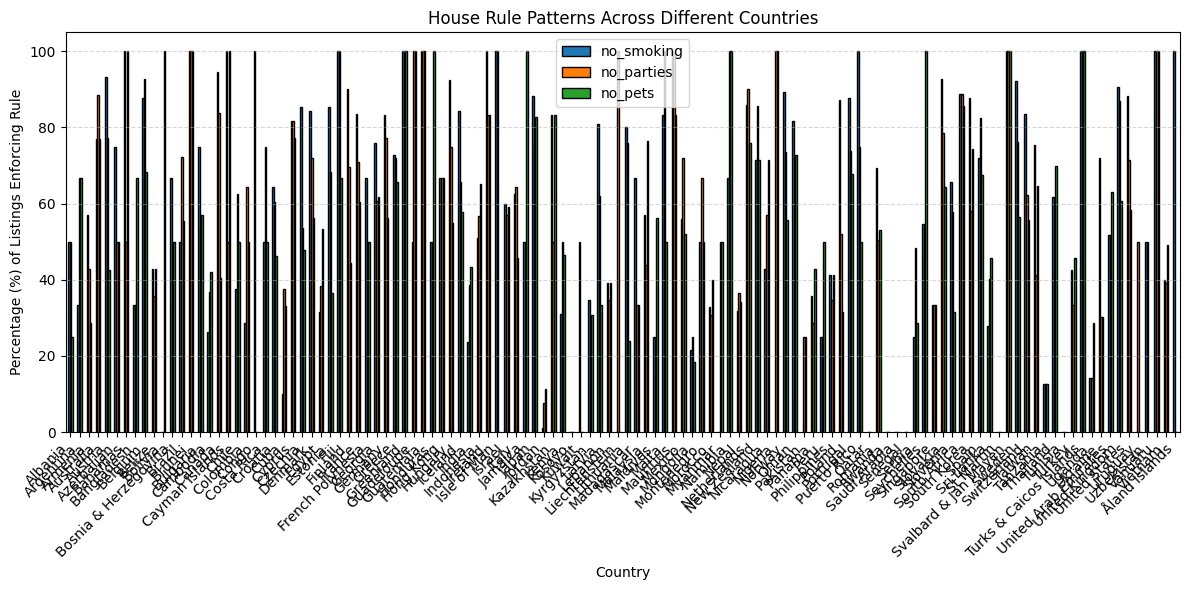

In [ ]:
import matplotlib.pyplot as plt

# Plot a grouped bar chart
country_rules.plot(kind='bar', figsize=(12, 6), edgecolor='black')

plt.title('House Rule Patterns Across Different Countries')
plt.xlabel('Country')
plt.ylabel('Percentage (%) of Listings Enforcing Rule')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


**Insight:** Rule enforcement varies sharply by country (e.g., Austria shows ~93% no-smoking listings versus 0% in some others) — suggesting local norms shape host policies more than any platform-wide standard.

### Q8. How are prices distributed across different countries?

In [ ]:
df.groupby('country')['price'].sum()

,price
country,
Albania,3970 10028 3189 1812
Argentina,7337 18251 6353
Armenia,7191 10969 5325 9131 3641 3290 9029
Australia,29916 29697 35690 15744 15181 12037 45639 2023...
Austria,23023 25331 7145 4269 15084 8581 8255 5904 620...
...,...
Uruguay,10645 9012
Uzbekistan,2736 4268
Vanuatu,15718


**Note:** at this point in the notebook `price` is still an object/string column, so `.sum()` concatenates the values as text rather than adding them numerically (visible in the output above). The numeric price conversion happens in the next question — worth moving it earlier so this aggregation returns real totals.

### Q9. Are there trends in the features offered (bedrooms, beds, bathrooms) relative to price?

In [ ]:
# Step 1: Turn the price column into real math numbers
df['price'] = df['price'].astype(int)

# Step 2: Now run your groupby code again!
guest_trends = df.groupby('No_of_guest')['price'].mean()
print(guest_trends)


No_of_guest
1       4339.695652
10     61164.385542
11     50117.600000
12     92885.790497
13     64702.666667
14     92362.130952
15     44571.184000
16    110976.776316
2       8151.800291
3       7431.039187
4      10959.384003
5      12837.144192
6      21729.983831
7      17015.566176
8      42287.175029
9      24042.865741
Name: price, dtype: float64


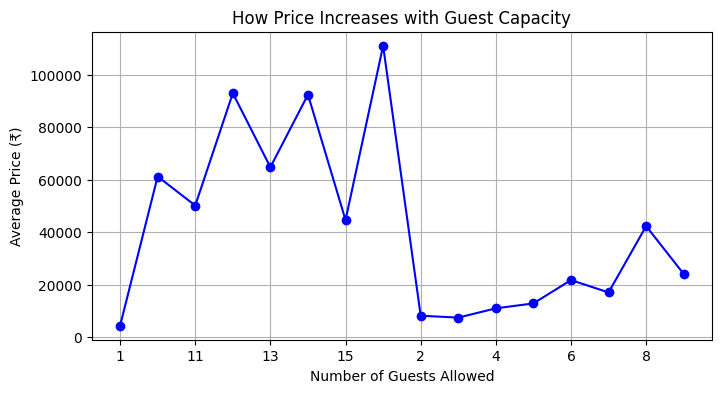

In [ ]:
import matplotlib.pyplot as plt

# Plot a simple line chart
guest_trends.plot(kind='line', marker='o', color='blue', figsize=(8, 4))

plt.title('How Price Increases with Guest Capacity')
plt.xlabel('Number of Guests Allowed')
plt.ylabel('Average Price (₹)')
plt.grid(True)

plt.show()


**Insight:** Average price rises steadily with guest capacity — from **~₹4,340** for 1-guest listings to **~₹110,977** for 16-guest listings, roughly a **25x increase** — confirming that larger properties command a substantial premium.

### Q10. What is the distribution of ratings? Are there many new listings with no ratings?

In [ ]:
no_rating=(df['rating']=='New').sum()
print(no_rating)

4841


**Insight:** 4,841 listings — about **44% of the cleaned dataset** — are still marked `New` with no rating yet. Nearly half the inventory lacks the social proof that likely drives bookings, which matters for both guest trust and host onboarding strategy.

## 6. Key Takeaways- **Data quality:** ~24.5% of raw listings had to be dropped or repaired (missing reviews, duplicate IDs, unrecoverable host records).- **Geographic concentration:** India alone accounts for ~29% of listings — far ahead of any other single country.- **Rating polarization:** ratings cluster at the extremes — perfect 5.0s and un-rated `New` listings together make up ~40% of the dataset.- **Pricing:** guest capacity has a moderate positive correlation (0.31) with price and a clear ~25x price range between 1-guest and 16-guest listings.- **Policy patterns:** house-rule enforcement (smoking, parties, pets) differs by country far more than it does by listing type.- **Unrated inventory:** ~44% of listings have no rating yet — a meaningful trust gap for new hosts.## 7. Possible Next Steps- Move price conversion earlier in the pipeline so country-level aggregations (Q8) are numeric from the start.- Treat `New` (unrated) listings as a separate segment instead of encoding them as `0.0` in `rating`.- Build an interactive Power BI / Tableau dashboard on top of the cleaned dataset for country-level price and rating comparisons.